# Playing Card Classification with EfficientNet-B0

This notebook builds an image classifier that recognizes **53 classes** of playing cards using transfer learning with EfficientNet-B0.

The optimal architecture was determined through a prior hyperparameter search using [Optuna](https://optuna.org/) (30 trials), which revealed that the simplest configuration — no added dense layers, no dropout, no batch normalization — outperformed all more complex alternatives.

**Workflow:**
1. **Data preparation** — Load images, balance classes via augmentation
2. **Model training** — Train the optimal EfficientNet-B0 architecture
3. **Evaluation** — Classification report and confusion matrix on the test set

## 1. Imports & Configuration

Set up all imports, define image size, batch size, training epochs, and directory paths. We also define a fixed seed for reproducibility.

In [1]:
import os
import numpy as np
import pandas as pd
import shutil
import tensorflow as tf
import random
import glob

print(f"TensorFlow: {tf.__version__}")

# Configuration
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 100
LEARNING_RATE = 0.00417

TRAIN_DIR = '/kaggle/input/cards-image-datasetclassification/train'
TEST_DIR = '/kaggle/input/cards-image-datasetclassification/test'
VALID_DIR = '/kaggle/input/cards-image-datasetclassification/valid'
WORKING_DIR = '/kaggle/working'

MODEL_PATH = os.path.join(WORKING_DIR, 'best_model.keras')

2026-02-09 17:02:30.186230: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770656550.368076      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770656550.415961      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770656550.828941      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770656550.828993      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770656550.829003      24 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0


## 2. Utility Functions

Four helper functions handle the data pipeline:
- **`set_seed`** — Ensures reproducible results across runs.
- **`make_dataframes`** — Scans the train/test/valid directories and builds DataFrames mapping file paths to labels.
- **`data_augmentation`** — Balances the dataset by generating augmented images for under-represented classes until each class reaches a target sample count.
- **`create_generators`** — Wraps the DataFrames into Keras `ImageDataGenerator` flows for training, validation, and testing.

In [2]:
def set_seed(seed=42):
    """Set random seeds for reproducibility."""
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

def make_dataframes(train_dir, test_dir, val_dir):
    """Create DataFrames with file paths and labels for each split."""
    dfs = {}
    for name, directory in [('train', train_dir), ('test', test_dir), ('valid', val_dir)]:
        filepaths = sorted(glob.glob(os.path.join(directory, '*', '*')))
        labels = [os.path.basename(os.path.dirname(f)) for f in filepaths]
        dfs[name] = pd.DataFrame({'filepaths': filepaths, 'labels': labels})
    classes = sorted(dfs['train']['labels'].unique())
    return dfs['train'], dfs['test'], dfs['valid'], classes

def data_augmentation(df, n_samples, working_dir, img_size):
    """Augment under-represented classes to reach n_samples per class."""
    df = df.copy()
    aug_dir = os.path.join(working_dir, 'augmented')
    shutil.rmtree(aug_dir, ignore_errors=True)

    aug_gen = tf.keras.preprocessing.image.ImageDataGenerator(
        horizontal_flip=True, rotation_range=20,
        width_shift_range=0.2, height_shift_range=0.2, zoom_range=0.2
    )

    for label, group in df.groupby('labels'):
        target_dir = os.path.join(aug_dir, label)
        os.makedirs(target_dir)
        delta = n_samples - len(group)
        if delta > 0:
            flow = aug_gen.flow_from_dataframe(
                group, x_col='filepaths', y_col=None,
                target_size=img_size, class_mode=None, batch_size=1,
                shuffle=False, save_to_dir=target_dir, save_prefix='aug-', save_format='jpg'
            )
            for _ in range(delta):
                next(flow)

    aug_paths = glob.glob(os.path.join(aug_dir, '*', '*'))
    aug_labels = [os.path.basename(os.path.dirname(f)) for f in aug_paths]
    aug_df = pd.DataFrame({'filepaths': aug_paths, 'labels': aug_labels})
    return pd.concat([df, aug_df], ignore_index=True)

def create_generators(train_df, test_df, valid_df, img_size, batch_size):
    """Create image data generators for training, validation, and test."""
    train_gen_obj = tf.keras.preprocessing.image.ImageDataGenerator(horizontal_flip=True)
    test_gen_obj = tf.keras.preprocessing.image.ImageDataGenerator()

    common = dict(x_col='filepaths', y_col='labels', target_size=img_size,
                  class_mode='categorical', color_mode='rgb')

    train_gen = train_gen_obj.flow_from_dataframe(train_df, **common, shuffle=True, batch_size=batch_size)
    valid_gen = test_gen_obj.flow_from_dataframe(valid_df, **common, shuffle=False, batch_size=batch_size)
    test_batch = max(n for n in range(1, min(81, len(test_df) + 1)) if len(test_df) % n == 0)
    test_gen = test_gen_obj.flow_from_dataframe(test_df, **common, shuffle=False, batch_size=test_batch)

    return train_gen, test_gen, valid_gen

## 3. Model Architecture

Based on the Optuna search (run separately in Colab), the optimal architecture turned out to be the **simplest possible**:

$$\text{EfficientNet-B0} \rightarrow \text{AveragePooling} \rightarrow \text{Dense}(53,\ \text{softmax})$$

No BatchNorm, no intermediate dense layers, no dropout. Key hyperparameters:
- **Optimizer:** Adamax
- **Learning rate:** 0.00417
- **Pooling:** Average

In [3]:
def create_model(num_classes, lr=0.00417):
    """
    Simplest possible model:
    EfficientNet-B0 -> AvgPooling -> Dense(53, softmax)

    No BatchNorm, no intermediate Dense, no Dropout.
    """
    base = tf.keras.applications.EfficientNetB0(
        include_top=False, weights='imagenet',
        input_shape=(224, 224, 3),
        pooling='avg'
    )
    base.trainable = True

    output = tf.keras.layers.Dense(num_classes, activation='softmax')(base.output)

    model = tf.keras.Model(inputs=base.input, outputs=output)
    model.compile(
        optimizer=tf.keras.optimizers.Adamax(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    print(f"Model created - Params: {model.count_params():,}")
    print(f"Architecture: EfficientNet-B0 -> AvgPool -> Dense({num_classes})")
    return model

## 4. Data Preparation & Training

### Load and balance the dataset

In [4]:
set_seed(42)

print("=" * 70)
print("Architecture: EfficientNet-B0 -> AvgPool -> Softmax (NO added layers)")
print("=" * 70)
print(f"Learning rate: {LEARNING_RATE}")
print(f"Max epochs: {EPOCHS}")

# 1. Load data
print("\n[1/5] Loading data...")
train_df, test_df, valid_df, classes = make_dataframes(TRAIN_DIR, TEST_DIR, VALID_DIR)
num_classes = len(classes)

# 2. Balance dataset
print("\n[2/5] Balancing dataset (200 samples per class)...")
train_df = data_augmentation(train_df, n_samples=200, working_dir=WORKING_DIR, img_size=IMG_SIZE)

# 3. Create generators
print("\n[3/5] Creating generators...")
train_gen, test_gen, valid_gen = create_generators(
    train_df, test_df, valid_df, IMG_SIZE, BATCH_SIZE
)

Architecture: EfficientNet-B0 -> AvgPool -> Softmax (NO added layers)
Learning rate: 0.00417
Max epochs: 100

[1/5] Loading data...

[2/5] Balancing dataset (200 samples per class)...
Found 120 validated image filenames.
Found 129 validated image filenames.
Found 171 validated image filenames.
Found 181 validated image filenames.
Found 138 validated image filenames.
Found 159 validated image filenames.
Found 152 validated image filenames.
Found 135 validated image filenames.
Found 150 validated image filenames.
Found 138 validated image filenames.
Found 136 validated image filenames.
Found 158 validated image filenames.
Found 157 validated image filenames.
Found 114 validated image filenames.
Found 154 validated image filenames.
Found 140 validated image filenames.
Found 171 validated image filenames.
Found 160 validated image filenames.
Found 168 validated image filenames.
Found 172 validated image filenames.
Found 115 validated image filenames.
Found 128 validated image filenames.
Fo

### Train the model

Train with three callbacks:
- **ModelCheckpoint** — Save the best weights (by validation loss).
- **EarlyStopping** — Stop if validation loss doesn't improve for 15 epochs, then restore best weights.
- **ReduceLROnPlateau** — Halve the learning rate after 5 epochs of stagnation.

In [5]:
# 4. Create model
print("\n[4/5] Creating model...")
model = create_model(num_classes, lr=LEARNING_RATE)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=MODEL_PATH, monitor='val_loss',
        save_best_only=True, mode='min', verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=15,
        restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=5, min_lr=1e-7, verbose=1
    )
]

# 5. Train
print("\n[5/5] Training model...")
history = model.fit(
    train_gen, epochs=EPOCHS, validation_data=valid_gen,
    callbacks=callbacks, verbose=1
)


[4/5] Creating model...


I0000 00:00:1770656644.327961      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1770656644.334046      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model created - Params: 4,117,464
Architecture: EfficientNet-B0 -> AvgPool -> Dense(53)

[5/5] Training model...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100


...

113/332 ━━━━━━━━━━━━━━━━━━━━ 29s 134ms/step - accuracy: 0.2622 - loss: 2.7871

2026-02-09 17:05:55.772941: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-09 17:05:55.908985: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-09 17:05:56.229059: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-09 17:05:56.370597: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-09 17:05:57.140509: E external/local_xla/xla/stream_

332/332 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.4628 - loss: 1.9496

2026-02-09 17:07:09.916454: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-09 17:07:10.053830: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-09 17:07:10.369653: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-09 17:07:10.511433: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-09 17:07:11.269479: E external/local_xla/xla/stream_


Epoch 1: val_loss improved from inf to 0.30834, saving model to /kaggle/working/best_model.keras
332/332 ━━━━━━━━━━━━━━━━━━━━ 189s 324ms/step - accuracy: 0.4634 - loss: 1.9474 - val_accuracy: 0.8868 - val_loss: 0.3083 - learning_rate: 0.0042
Epoch 2/100
332/332 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.8809 - loss: 0.4042
Epoch 2: val_loss improved from 0.30834 to 0.16821, saving model to /kaggle/working/best_model.keras
332/332 ━━━━━━━━━━━━━━━━━━━━ 44s 133ms/step - accuracy: 0.8809 - loss: 0.4041 - val_accuracy: 0.9585 - val_loss: 0.1682 - learning_rate: 0.0042
Epoch 3/100
332/332 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.9251 - loss: 0.2599
Epoch 3: val_loss did not improve from 0.16821
332/332 ━━━━━━━━━━━━━━━━━━━━ 45s 136ms/step - accuracy: 0.9251 - loss: 0.2599 - val_accuracy: 0.9547 - val_loss: 0.1831 - learning_rate: 0.0042
Epoch 4/100
332/332 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.9487 - loss: 0.1761
Epoch 4: val_loss did not improve from 0.16821
332/332

### Test Set Evaluation

Load the best saved checkpoint and evaluate on the held-out test set.

In [6]:
print("\n" + "=" * 70)
print("TEST SET EVALUATION")
print("=" * 70)

best_model = tf.keras.models.load_model(MODEL_PATH)
test_gen.reset()
results = best_model.evaluate(test_gen, verbose=0)

print(f"\n{'=' * 50}")
print(f"TEST RESULTS:")
print(f"  Loss:     {results[0]:.4f}")
print(f"  Accuracy: {results[1] * 100:.2f}%")
print(f"{'=' * 50}")


TEST SET EVALUATION


2026-02-09 17:52:35.204671: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-09 17:52:35.359701: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-09 17:52:35.753699: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-09 17:52:35.896062: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-09 17:52:36.682601: E external/local_xla/xla/stream_


TEST RESULTS:
  Loss:     0.0108
  Accuracy: 99.62%


### Training Curves

Loss and accuracy over epochs for both training and validation sets.

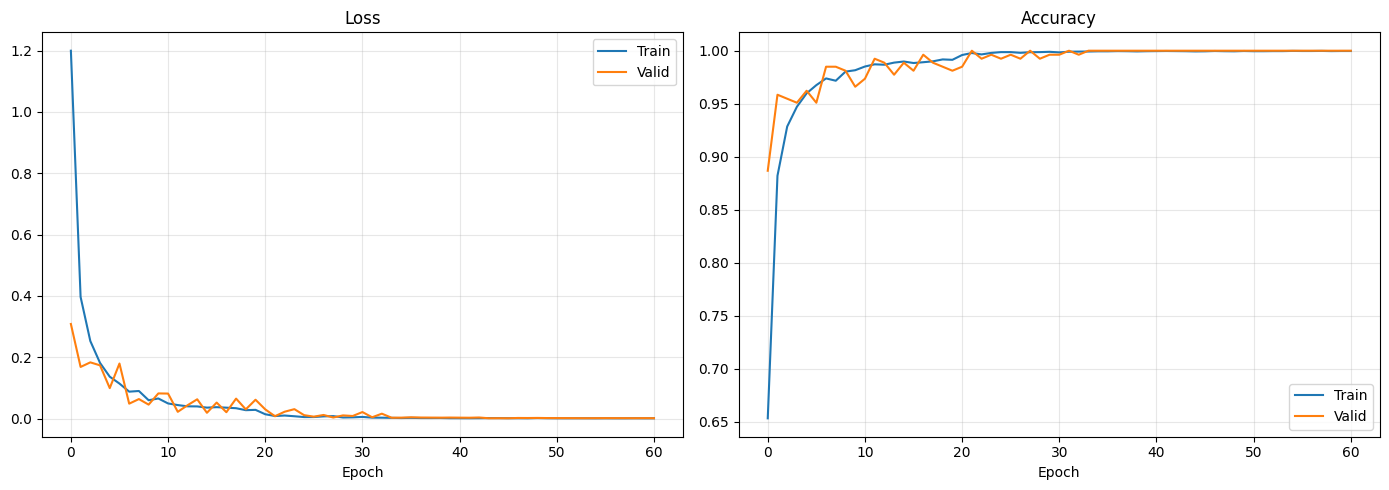

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Valid')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Train')
axes[1].plot(history.history['val_accuracy'], label='Valid')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Detailed Evaluation

Generate predictions on the full test set and inspect per-class precision, recall, and F1-score. The confusion matrix highlights which card classes are most commonly confused.

In [8]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

test_gen.reset()
y_pred_probs = best_model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())

print("\nCLASSIFICATION REPORT")
print("=" * 70)
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 121ms/step

CLASSIFICATION REPORT
                   precision    recall  f1-score   support

     ace of clubs     1.0000    1.0000    1.0000         5
  ace of diamonds     1.0000    1.0000    1.0000         5
    ace of hearts     1.0000    1.0000    1.0000         5
    ace of spades     1.0000    1.0000    1.0000         5
   eight of clubs     1.0000    1.0000    1.0000         5
eight of diamonds     1.0000    1.0000    1.0000         5
  eight of hearts     1.0000    1.0000    1.0000         5
  eight of spades     1.0000    1.0000    1.0000         5
    five of clubs     1.0000    1.0000    1.0000         5
 five of diamonds     1.0000    1.0000    1.0000         5
   five of hearts     1.0000    1.0000    1.0000         5
   five of spades     1.0000    1.0000    1.0000         5
    four of clubs     1.0000    1.0000    1.0000         5
 four of diamonds     1.0000    1.0000    1.0000         5
   four of hearts     1.0000    1.0000    1.0000    

## 6. Conclusions

The final EfficientNet-B0 model achieves strong accuracy on the 53-class playing card classification task, and notably, the Optuna search revealed that the simplest architecture, with no additional dense layers, dropout, or batch normalization, outperformed all more complex configurations. This is a good reminder that a powerful backbone often needs very little on top.

**A note on the dataset:** The Cards dataset is relatively clean and well-structured, but class imbalance is noticeable, some cards have significantly fewer samples than others. The augmentation step (padding each class to 200 samples) helps, but a more aggressive strategy or a larger base dataset could further improve performance on the weaker classes. Testing on out-of-distribution images would be a valuable next step.